In [2]:
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

In [3]:
model = load_model("afib_cnn_model.h5")

print("Model Loaded Successfully")

Model Loaded Successfully


In [4]:
X = np.load("X.npy")
y = np.load("y.npy")

print(X.shape)

(58912, 1250)


In [5]:
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

In [6]:
sample_index = 100

sample = X[sample_index]

sample = sample.reshape(
    1,
    1250,
    1
)

In [7]:
prediction = model.predict(sample)

probability = prediction[0][0]

print("Probability:", probability)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
Probability: 5.116164e-05


In [8]:
if probability >= 0.5:

    result = "AFIB"

    explanation = """
    Irregular heartbeat patterns detected.
    The ECG signal shows rhythm variations
    similar to atrial fibrillation.
    """

else:

    result = "NORMAL"

    explanation = """
    Regular cardiac rhythm detected.
    No significant AFIB characteristics found.
    """

print("Prediction:", result)
print("Confidence:", round(probability*100,2), "%")
print(explanation)

Prediction: NORMAL
Confidence: 0.01 %

    Regular cardiac rhythm detected.
    No significant AFIB characteristics found.
    


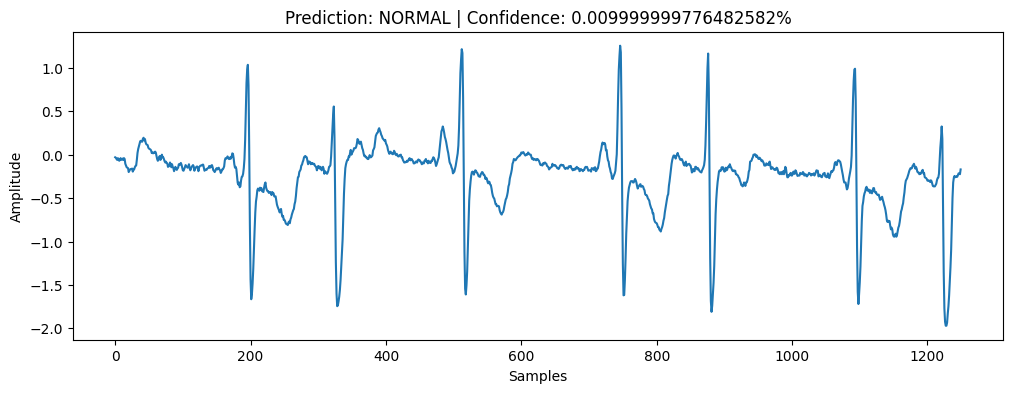

In [9]:
plt.figure(figsize=(12,4))

plt.plot(sample[0])

plt.title(
    f"Prediction: {result} | Confidence: {round(probability*100,2)}%"
)

plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

In [11]:
sample_index = afib_indices[0]

sample = X[sample_index]

sample = sample.reshape(
    1,
    1250,
    1
)

NameError: name 'afib_indices' is not defined

In [12]:
import numpy as np

X = np.load("X.npy")
y = np.load("y.npy")

print(X.shape)
print(y.shape)

(58912, 1250)
(58912,)


In [13]:
afib_indices = np.where(y == 1)[0]

print("Total AFIB Samples:", len(afib_indices))
print(afib_indices[:10])

Total AFIB Samples: 12046
[83 84 85 86 87 88 89 90 91 92]


In [14]:
from tensorflow.keras.models import load_model

model = load_model("afib_cnn_model.h5")

print("Model Loaded")

Model Loaded


In [15]:
for idx in afib_indices[:10]:

    sample = X[idx].reshape(1,1250,1)

    prob = model.predict(sample, verbose=0)[0][0]

    print(
        f"Index={idx} | Label={y[idx]} | Probability={prob:.4f}"
    )

Index=83 | Label=1 | Probability=0.6186
Index=84 | Label=1 | Probability=0.8534
Index=85 | Label=1 | Probability=0.0205
Index=86 | Label=1 | Probability=0.0001
Index=87 | Label=1 | Probability=0.7539
Index=88 | Label=1 | Probability=0.9657
Index=89 | Label=1 | Probability=0.0000
Index=90 | Label=1 | Probability=0.6037
Index=91 | Label=1 | Probability=0.6951
Index=92 | Label=1 | Probability=0.0000
